# 02 - RFM Calculation & Customer Segmentation

Builds Recency, Frequency, Monetary metrics per customer from the cleaned
transaction table, scores each on a 1-5 quintile scale, and maps the
R/F score combination to named, business-actionable segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

CLEAN_PATH = "../data/processed/online_retail_clean.csv"
RFM_OUTPUT_PATH = "../data/processed/rfm_segments.csv"

# Palette (single-hue blue ramp, light -> dark) used for every chart below
BAR_COLOR = "#2a78d6"
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SEQ_RAMP = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"]

plt.rcParams.update({
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_MUTED,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "font.size": 10,
})

df = pd.read_csv(CLEAN_PATH, parse_dates=["InvoiceDate"])
df.shape

(391068, 9)

## 1. Define the snapshot date

RFM measures recency "as of today". Since this is historical data, we use
the day *after* the last recorded transaction as our reference point —
this mirrors how the analysis would run in production, where "today" is
always one day after the most recent data load.

In [2]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


## 2. Aggregate to customer level: Recency, Frequency, Monetary

In [3]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print("Customers:", rfm.shape[0])
rfm.head()

Customers: 4334


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


In [4]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.703046,4.245270,2015.690042
std,100.177047,7.634633,8903.655720
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.240000
50%,51.000000,2.000000,661.420000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


## 3. Score each metric 1-5 using quintiles

Customers are ranked into 5 equal-sized buckets per metric. Recency is
**inverted** (a *low* Recency = recently active = best = score 5), while
Frequency and Monetary score directly (higher = better = score 5).

We rank with `.rank(method="first")` before `qcut` to break ties — RFM
data is heavily tied (many customers share Frequency=1), which otherwise
makes `qcut` fail with "Bin edges must be unique".

In [5]:
r_labels = range(5, 0, -1)
f_labels = range(1, 6)
m_labels = range(1, 6)

rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"), q=5, labels=r_labels).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=f_labels).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=m_labels).astype(int)

rfm[["Recency", "R_Score", "Frequency", "F_Score", "Monetary", "M_Score"]].head(10)

,Recency,R_Score,Frequency,F_Score,Monetary,M_Score
0,326,1,1,1,77183.60,5
1,2,5,7,5,4310.00,5
2,75,2,4,4,1437.24,4
3,19,4,1,1,1457.55,4
4,310,1,1,1,294.40,2
5,36,3,7,5,1385.74,4
6,204,1,1,1,89.00,1
7,232,1,1,1,1079.40,4
8,214,1,1,1,459.40,2
9,23,4,3,3,2487.43,5


In [6]:
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm["RF_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str)

## 4. Map R/F score combinations to named segments

This is the standard 5x5 RFM segment map used across CRM/retention teams.
It's built primarily on **Recency + Frequency** (Monetary correlates
heavily with Frequency and is used later to weight business impact, not
to define the label itself). Read each key as a regex over the 2-digit
"RF" string, e.g. `"[4-5][4-5]"` matches R=4or5 AND F=4or5.

In [7]:
segment_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Can't Lose Them",
    r"3[1-2]": "About to Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions",
}

rfm["Segment"] = rfm["RF_Score"].replace(segment_map, regex=True)
rfm["Segment"].value_counts()

Segment
Hibernating            1078
Loyal Customers         817
Champions               633
At Risk                 591
Potential Loyalists     477
About to Sleep          346
Need Attention          190
Promising                96
Can't Lose Them          65
New Customers            41
Name: count, dtype: int64

## 5. Business view: size and revenue contribution per segment

Customer *count* alone can be misleading — a business cares which
segments actually drive revenue. We report both side by side.

In [8]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "nunique"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).round(1)

segment_summary["Pct_Customers"] = (segment_summary["Customers"] / segment_summary["Customers"].sum() * 100).round(1)
segment_summary["Pct_Revenue"] = (segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100).round(1)

segment_summary = segment_summary.sort_values("Total_Revenue", ascending=False)
segment_summary

,Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
Segment,,,,,,,
Champions,633,5.9,12.3,6769.2,4284919.3,14.6,49.0
Loyal Customers,817,33.0,6.4,2781.3,2272362.1,18.9,26.0
At Risk,591,152.5,2.9,1072.5,633821.0,13.6,7.3
Hibernating,1078,217.0,1.1,478.5,515844.9,24.9,5.9
Potential Loyalists,477,16.6,2.0,1025.2,489030.0,11.0,5.6
Can't Lose Them,65,132.8,8.3,2717.1,176611.9,1.5,2.0
Need Attention,190,51.2,2.3,832.3,158127.5,4.4,1.8
About to Sleep,346,52.6,1.1,452.1,156427.3,8.0,1.8
Promising,96,23.0,1.0,350.4,33640.9,2.2,0.4


## 6. Visualize: customers vs. revenue contribution per segment

Two single-metric charts (not a dual-axis combo) sorted the same way, so
a segment that looks small in customer count but large in revenue (or
vice versa) stands out clearly across both panels.

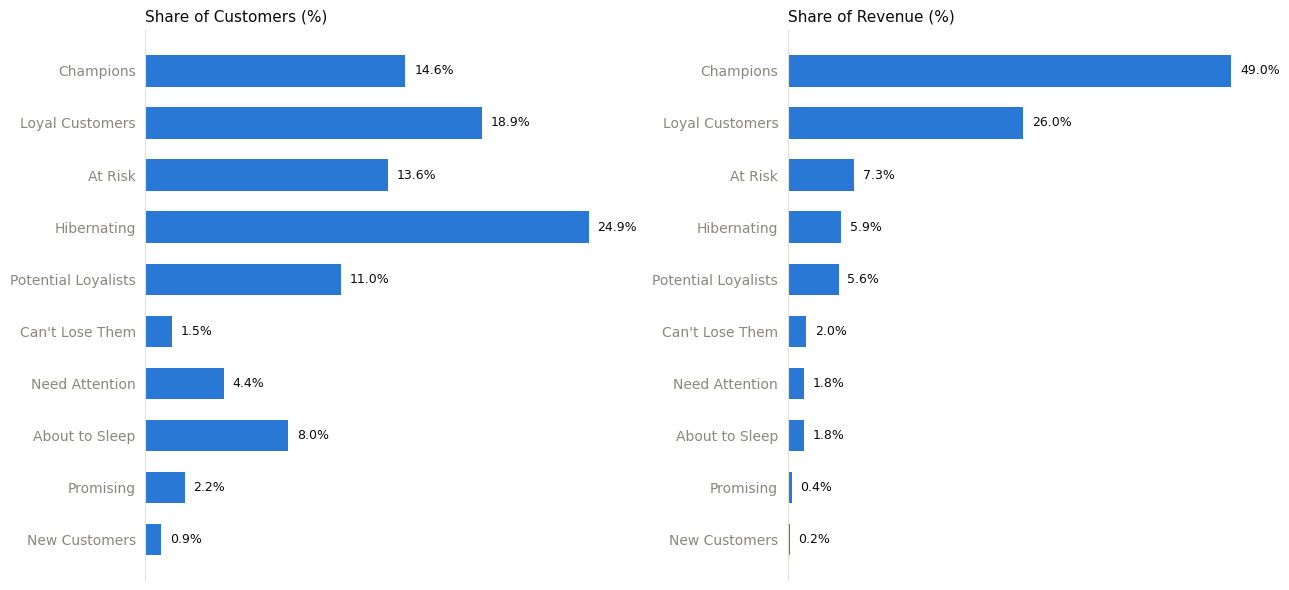

In [9]:
order = segment_summary.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, col, title, fmt in [
    (axes[0], "Pct_Customers", "Share of Customers (%)", "{:.1f}%"),
    (axes[1], "Pct_Revenue", "Share of Revenue (%)", "{:.1f}%"),
]:
    values = segment_summary.loc[order, col]
    bars = ax.barh(order, values, color=BAR_COLOR, height=0.6)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontsize=11, color=INK_PRIMARY)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.xaxis.set_visible(False)
    ax.tick_params(left=False)
    for bar, v in zip(bars, values):
        ax.text(bar.get_width() + values.max() * 0.02, bar.get_y() + bar.get_height() / 2,
                fmt.format(v), va="center", fontsize=9, color=INK_PRIMARY)

plt.tight_layout()
plt.savefig("../outputs/segment_customers_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Visualize: the R x F grid

A heatmap of how many customers fall into each Recency x Frequency score
combination doubles as documentation for the segment map above — you can
see exactly which cells were grouped into which named segment.

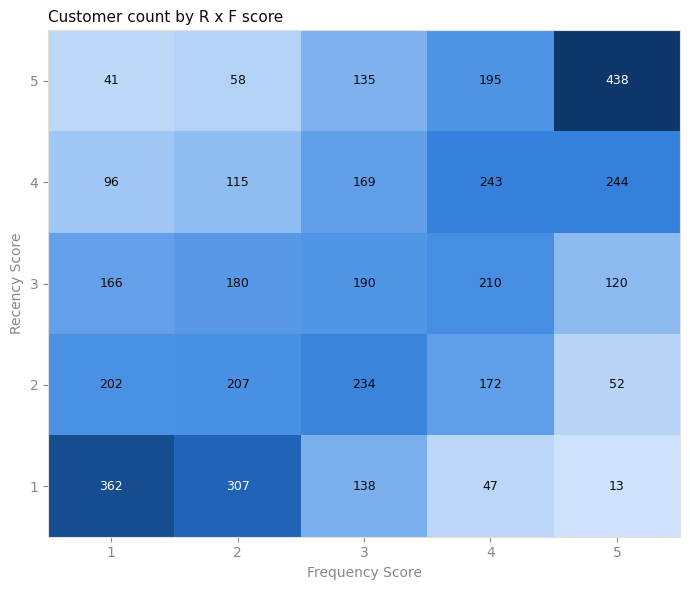

In [10]:
grid = rfm.pivot_table(index="R_Score", columns="F_Score", values="CustomerID", aggfunc="count", fill_value=0)
grid = grid.sort_index(ascending=False)  # R=5 (best) at the top

cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_RAMP)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid.values, cmap=cmap, aspect="auto")

ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels(grid.columns)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index)
ax.set_xlabel("Frequency Score")
ax.set_ylabel("Recency Score")
ax.set_title("Customer count by R x F score", loc="left", fontsize=11, color=INK_PRIMARY)

# Direct labels: count per cell, text color flips for contrast on dark cells
vmax = grid.values.max()
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        val = grid.values[i, j]
        color = "white" if val > vmax * 0.6 else INK_PRIMARY
        ax.text(j, i, str(val), ha="center", va="center", fontsize=9, color=color)

plt.tight_layout()
plt.savefig("../outputs/rf_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Export

In [11]:
rfm.to_csv(RFM_OUTPUT_PATH, index=False)
print(f"Saved RFM + segments to {RFM_OUTPUT_PATH}")
print(f"\nTotal customers segmented: {rfm['CustomerID'].nunique()}")
print(f"Segments: {rfm['Segment'].nunique()}")

Saved RFM + segments to ../data/processed/rfm_segments.csv

Total customers segmented: 4334
Segments: 10
